In [43]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.datasets import load_breast_cancer
from sklearn.metrics import classification_report,confusion_matrix,accuracy_score
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings('ignore')

In [44]:
columns = [
    "class", "cap-shape", "cap-surface", "cap-color", "bruises",
    "odor", "gill-attachment", "gill-spacing", "gill-size", "gill-color",
    "stalk-shape", "stalk-root", "stalk-surface-above-ring",
    "stalk-surface-below-ring", "stalk-color-above-ring",
    "stalk-color-below-ring", "veil-type", "veil-color",
    "ring-number", "ring-type", "spore-print-color",
    "population", "habitat"
]

In [45]:
m = pd.read_csv(
    r"C:\Users\deeks\OneDrive\Desktop\ML\mushroom\agaricus-lepiota.data",
    header=None
)

print(m.shape)
print(m.head())

(8124, 23)
  0  1  2  3  4  5  6  7  8  9   ... 13 14 15 16 17 18 19 20 21 22
0  p  x  s  n  t  p  f  c  n  k  ...  s  w  w  p  w  o  p  k  s  u
1  e  x  s  y  t  a  f  c  b  k  ...  s  w  w  p  w  o  p  n  n  g
2  e  b  s  w  t  l  f  c  b  n  ...  s  w  w  p  w  o  p  n  n  m
3  p  x  y  w  t  p  f  c  n  n  ...  s  w  w  p  w  o  p  k  s  u
4  e  x  s  g  f  n  f  w  b  k  ...  s  w  w  p  w  o  e  n  a  g

[5 rows x 23 columns]


In [46]:
m.columns = columns

In [47]:
m.head()

,class,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
0,p,x,s,n,t,p,f,c,n,k,...,s,w,w,p,w,o,p,k,s,u
1,e,x,s,y,t,a,f,c,b,k,...,s,w,w,p,w,o,p,n,n,g
2,e,b,s,w,t,l,f,c,b,n,...,s,w,w,p,w,o,p,n,n,m
3,p,x,y,w,t,p,f,c,n,n,...,s,w,w,p,w,o,p,k,s,u
4,e,x,s,g,f,n,f,w,b,k,...,s,w,w,p,w,o,e,n,a,g


In [48]:
m.to_csv("mushroom_cleaned.csv", index=False)

In [49]:
import os
print(os.getcwd())

c:\Users\deeks\OneDrive\Desktop


In [50]:
m.shape

(8124, 23)

In [51]:
m.isnull().sum()

class                       0
cap-shape                   0
cap-surface                 0
cap-color                   0
bruises                     0
odor                        0
gill-attachment             0
gill-spacing                0
gill-size                   0
gill-color                  0
stalk-shape                 0
stalk-root                  0
stalk-surface-above-ring    0
stalk-surface-below-ring    0
stalk-color-above-ring      0
stalk-color-below-ring      0
veil-type                   0
veil-color                  0
ring-number                 0
ring-type                   0
spore-print-color           0
population                  0
habitat                     0
dtype: int64

In [52]:
m = m.fillna(m[columns].mode().iloc[0])

# My Target

In [53]:
m["class"].unique()

array(['p', 'e'], dtype=object)

In [54]:
m["class"]=m["class"].map({'EDIBLE':1 , 'POISONOUS':0})

# Encoding Features

In [55]:
m = pd.get_dummies(m, drop_first=True)

In [56]:
m.head()

,class,cap-shape_c,cap-shape_f,cap-shape_k,cap-shape_s,cap-shape_x,cap-surface_g,cap-surface_s,cap-surface_y,cap-color_c,...,population_n,population_s,population_v,population_y,habitat_g,habitat_l,habitat_m,habitat_p,habitat_u,habitat_w
0,NaN,False,False,False,False,True,False,True,False,False,...,False,True,False,False,False,False,False,False,True,False
1,NaN,False,False,False,False,True,False,True,False,False,...,True,False,False,False,True,False,False,False,False,False
2,NaN,False,False,False,False,False,False,True,False,False,...,True,False,False,False,False,False,True,False,False,False
3,NaN,False,False,False,False,True,False,False,True,False,...,False,True,False,False,False,False,False,False,True,False
4,NaN,False,False,False,False,True,False,True,False,False,...,False,False,False,False,True,False,False,False,False,False


In [57]:
m = m.fillna(m.mode().iloc[0])

In [58]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in m.columns:
    m[col] = le.fit_transform(m[col])

In [59]:
m.head()

,class,cap-shape_c,cap-shape_f,cap-shape_k,cap-shape_s,cap-shape_x,cap-surface_g,cap-surface_s,cap-surface_y,cap-color_c,...,population_n,population_s,population_v,population_y,habitat_g,habitat_l,habitat_m,habitat_p,habitat_u,habitat_w
0,0,0,0,0,0,1,0,1,0,0,...,0,1,0,0,0,0,0,0,1,0
1,0,0,0,0,0,1,0,1,0,0,...,1,0,0,0,1,0,0,0,0,0
2,0,0,0,0,0,0,0,1,0,0,...,1,0,0,0,0,0,1,0,0,0
3,0,0,0,0,0,1,0,0,1,0,...,0,1,0,0,0,0,0,0,1,0
4,0,0,0,0,0,1,0,1,0,0,...,0,0,0,0,1,0,0,0,0,0


In [60]:
m.shape

(8124, 96)

In [61]:
x=m.drop("class",axis=1) 
y=m["class"]
X_train,X_test,Y_train,Y_test=train_test_split(x,y,test_size=0.2,random_state=42,stratify=y)

In [62]:
from sklearn.tree import DecisionTreeClassifier
DT = DecisionTreeClassifier(random_state=42)
DT.fit(X_train, Y_train)

DecisionTreeClassifier(random_state=42)

In [63]:
Y_pred=DT.predict(X_test)

In [64]:
acc = accuracy_score(Y_test, Y_pred)
print("Accuracy:", acc)

Accuracy: 1.0


In [65]:
print(classification_report(Y_test, Y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1625

    accuracy                           1.00      1625
   macro avg       1.00      1.00      1.00      1625
weighted avg       1.00      1.00      1.00      1625



In [66]:
cm = confusion_matrix(Y_test, Y_pred)
print(cm)

[[1625]]


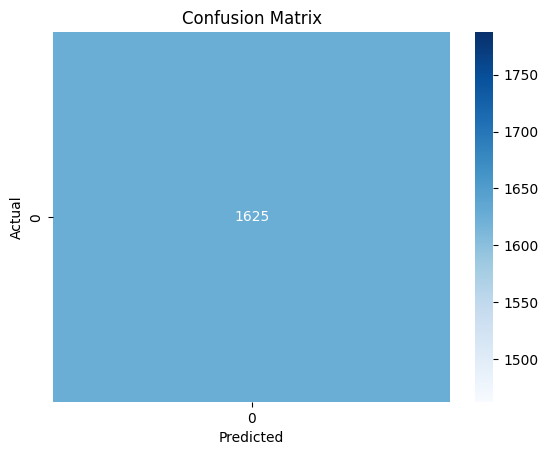

In [67]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

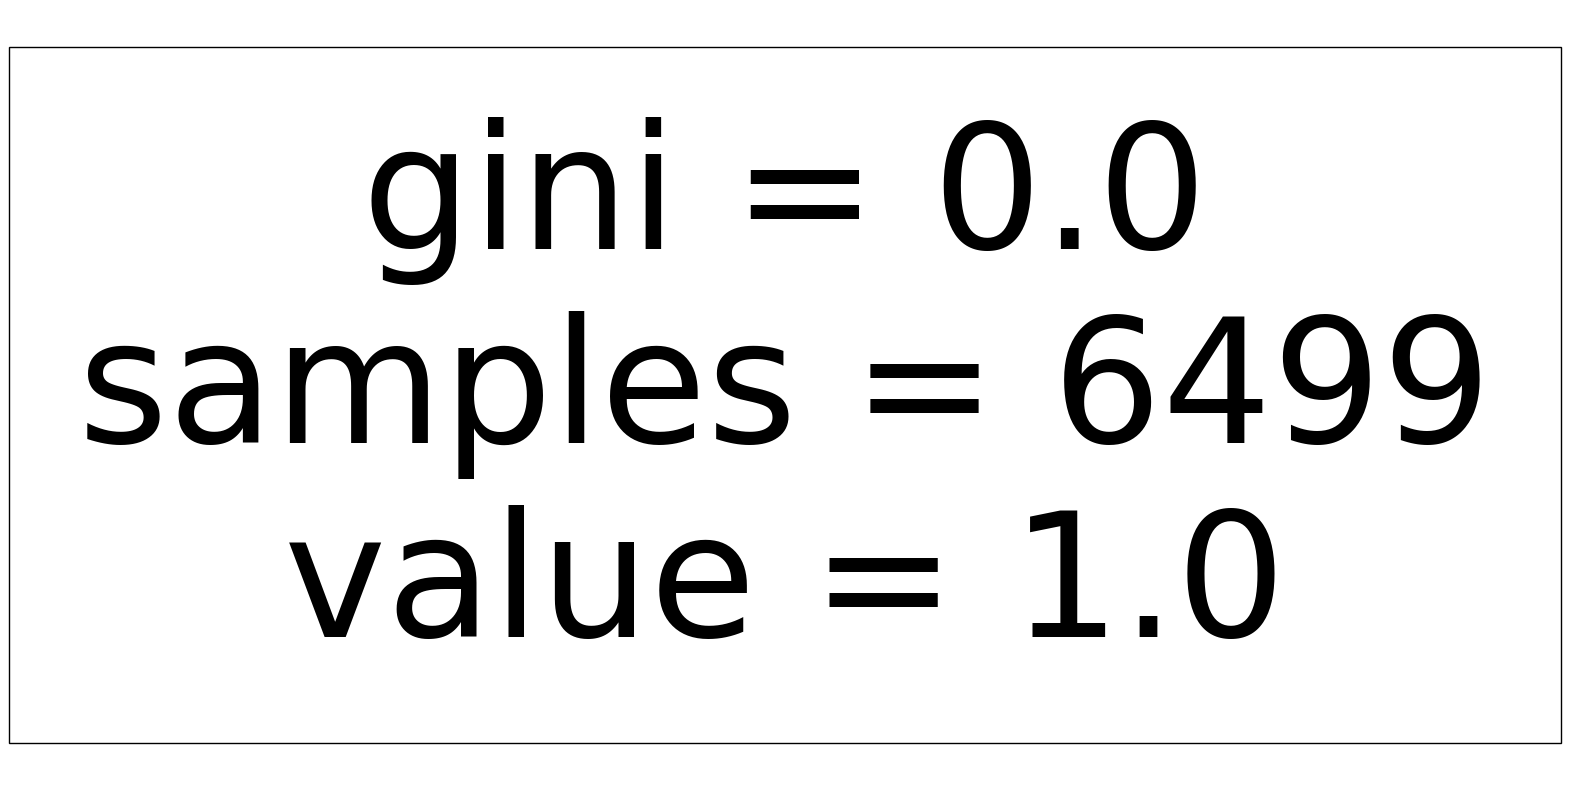

In [68]:
from sklearn.tree import plot_tree
plt.figure(figsize=(20,10))
plot_tree(DT, filled=True, feature_names=x.columns)
plt.show()

In [69]:
from sklearn.metrics import accuracy_score

results = []

for depth in [3, 5, 10]:
    for split in [2, 5, 10]:
        for leaf in [1, 2, 4]:
            
            model = DecisionTreeClassifier(
                max_depth=depth,
                min_samples_split=split,
                min_samples_leaf=leaf,
                random_state=42
            )
            
            model.fit(X_train, Y_train)
            pred = model.predict(X_test)
            
            acc = accuracy_score(Y_test, pred)
            
            results.append((depth, split, leaf, acc))

In [70]:
for r in results:
    print(f"Depth={r[0]}, Split={r[1]}, Leaf={r[2]} → Accuracy={r[3]}")

Depth=3, Split=2, Leaf=1 → Accuracy=1.0
Depth=3, Split=2, Leaf=2 → Accuracy=1.0
Depth=3, Split=2, Leaf=4 → Accuracy=1.0
Depth=3, Split=5, Leaf=1 → Accuracy=1.0
Depth=3, Split=5, Leaf=2 → Accuracy=1.0
Depth=3, Split=5, Leaf=4 → Accuracy=1.0
Depth=3, Split=10, Leaf=1 → Accuracy=1.0
Depth=3, Split=10, Leaf=2 → Accuracy=1.0
Depth=3, Split=10, Leaf=4 → Accuracy=1.0
Depth=5, Split=2, Leaf=1 → Accuracy=1.0
Depth=5, Split=2, Leaf=2 → Accuracy=1.0
Depth=5, Split=2, Leaf=4 → Accuracy=1.0
Depth=5, Split=5, Leaf=1 → Accuracy=1.0
Depth=5, Split=5, Leaf=2 → Accuracy=1.0
Depth=5, Split=5, Leaf=4 → Accuracy=1.0
Depth=5, Split=10, Leaf=1 → Accuracy=1.0
Depth=5, Split=10, Leaf=2 → Accuracy=1.0
Depth=5, Split=10, Leaf=4 → Accuracy=1.0
Depth=10, Split=2, Leaf=1 → Accuracy=1.0
Depth=10, Split=2, Leaf=2 → Accuracy=1.0
Depth=10, Split=2, Leaf=4 → Accuracy=1.0
Depth=10, Split=5, Leaf=1 → Accuracy=1.0
Depth=10, Split=5, Leaf=2 → Accuracy=1.0
Depth=10, Split=5, Leaf=4 → Accuracy=1.0
Depth=10, Split=10, Leaf=1 →

In [71]:
best = max(results, key=lambda x: x[3])
print("Best Params:", best)

Best Params: (3, 2, 1, 1.0)


In [72]:
df_results = pd.DataFrame(results, columns=[
    "max_depth", "min_samples_split", "min_samples_leaf", "accuracy"
])

print(df_results)

    max_depth  min_samples_split  min_samples_leaf  accuracy
0           3                  2                 1       1.0
1           3                  2                 2       1.0
2           3                  2                 4       1.0
3           3                  5                 1       1.0
4           3                  5                 2       1.0
5           3                  5                 4       1.0
6           3                 10                 1       1.0
7           3                 10                 2       1.0
8           3                 10                 4       1.0
9           5                  2                 1       1.0
10          5                  2                 2       1.0
11          5                  2                 4       1.0
12          5                  5                 1       1.0
13          5                  5                 2       1.0
14          5                  5                 4       1.0
15          5           

In [73]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(DT, x, y, cv=5)
print("Cross-validation scores:", scores)
print("Average Accuracy:", scores.mean())

Cross-validation scores: [1. 1. 1. 1. 1.]
Average Accuracy: 1.0
